## Importing & Preprocessing

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [17]:
# import datasets
df_sentiment140 = pd.read_csv('sentiment140.csv', encoding='latin1', header=None)
test_set = pd.read_csv("new_test_set.csv", encoding='latin1')

In [18]:
# Sentiment140 Preprocessing

df_sentiment140.columns = ['target', 'id', 'date', 'flag', 'user', 'Tweet']
df_sentiment140['source'] = 'Sentiment140'

# Standardize labels
label_mapping = {0: 'negative', 4: 'positive'}
df_sentiment140['sentiment'] = df_sentiment140['target'].map(label_mapping)

# basic function to clean tweets
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Remove mentions
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)  # Remove hashtags
    text = re.sub(r'[^A-Za-z0-9 ]+', '', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    return text

df_sentiment140['Tweet'] = df_sentiment140['Tweet'].apply(clean_text)

# Balance the dataset

print(df_sentiment140['sentiment'].value_counts())

# Example: Undersample to balance the dataset
min_class = df_sentiment140['sentiment'].value_counts().min()
df_sentiment140_balanced = df_sentiment140.groupby('sentiment').apply(lambda x: x.sample(min_class)).reset_index(drop=True)

sentiment
negative    800000
positive    248576
Name: count, dtype: int64


/scratch/1453916.1.academic/ipykernel_2996809/844931272.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sentiment140_balanced = df_sentiment140.groupby('sentiment').apply(lambda x: x.sample(min_class)).reset_index(drop=True)


In [19]:
full_data = df_sentiment140_balanced.copy()

# sample to reduce training time (250,000 tweets)
data = full_data.sample(n=250000, replace=True, random_state=340)

## Model 1

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2024-12-08 21:06:21.477925: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 354s 56ms/step - accuracy: 0.7582 - loss: 0.4912 - val_accuracy: 0.8036 - val_loss: 0.4256
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 350s 56ms/step - accuracy: 0.8281 - loss: 0.3802 - val_accuracy: 0.8203 - val_loss: 0.3986
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 351s 56ms/step - accuracy: 0.8572 - loss: 0.3242 - val_accuracy: 0.8250 - val_loss: 0.4030
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 350s 56ms/step - accuracy: 0.8852 - loss: 0.2694 - val_accuracy: 0.8291 - val_loss: 0.4186
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 342s 55ms/step - accuracy: 0.9077 - loss: 0.2220 - val_accuracy: 0.8319 - val_loss: 0.4449
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 338s 54ms/step - accuracy: 0.9259 - loss: 0.1820 - val_accuracy: 0.8323 - val_loss: 0.5151
Epoch 7/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 341s 55ms/step - accuracy: 0.9415 - loss: 0.1466 - val_accuracy: 0.8329 - val_loss: 0.5665
Epoch 8/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 340s 54ms/step - accuracy: 0.9543 - lo

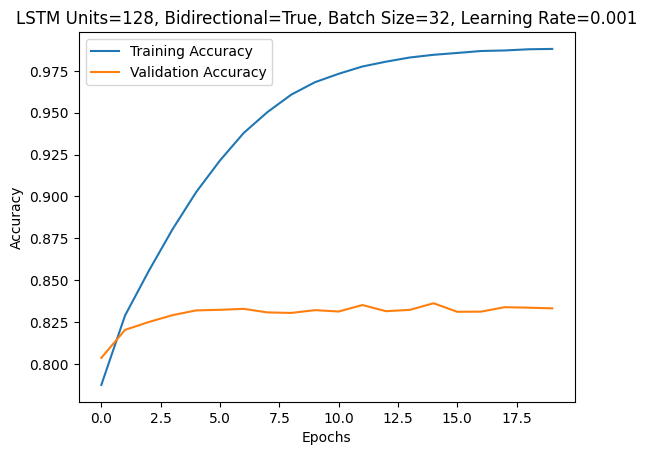

In [5]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)
val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128      
bidirectional = True   
batch_size = 32        
learning_rate = 0.001  

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dense(1, activation='sigmoid'))  
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    verbose=1
)

# 7. Evaluate on the Trump test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



In [6]:
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_pred, y_val))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
[[138  92]
 [ 52 218]]
0.712


In [6]:
model.save("lstm_model_1.h5")

In [7]:
plt.savefig("model_1_plot")

<Figure size 640x480 with 0 Axes>

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


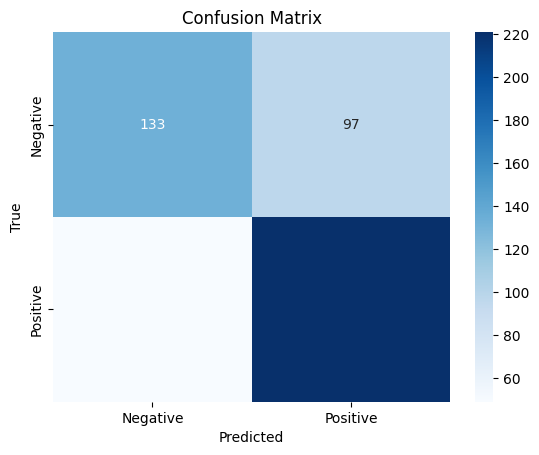

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.58      0.65       230
    Positive       0.69      0.82      0.75       270

    accuracy                           0.71       500
   macro avg       0.71      0.70      0.70       500
weighted avg       0.71      0.71      0.70       500



In [8]:
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))


In [9]:
plt.savefig('model1_cr.png')

<Figure size 640x480 with 0 Axes>

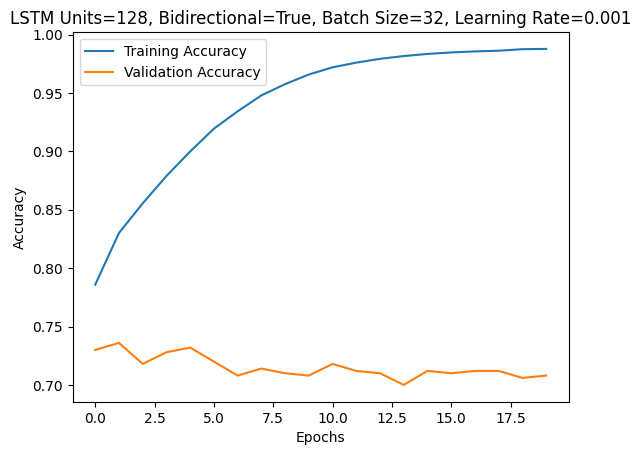

In [10]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [11]:
plt.savefig("model_1_plot")

<Figure size 640x480 with 0 Axes>

## Model 1 - Regularization

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 345s 55ms/step - accuracy: 0.7558 - loss: 0.4958 - val_accuracy: 0.8072 - val_loss: 0.4225
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 335s 54ms/step - accuracy: 0.8263 - loss: 0.3845 - val_accuracy: 0.8179 - val_loss: 0.4054
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 340s 54ms/step - accuracy: 0.8525 - loss: 0.3345 - val_accuracy: 0.8220 - val_loss: 0.4015
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 340s 54ms/step - accuracy: 0.8746 - loss: 0.2922 - val_accuracy: 0.8258 - val_loss: 0.4156
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 340s 54ms/step - accuracy: 0.8929 - loss: 0.2513 - val_accuracy: 0.8271 - val_loss: 0.4360
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 341s 54ms/step - accuracy: 0.9092 - loss: 0.2154 - val_accuracy: 0.8285 - val_loss: 0.4790
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7121 - loss: 1.2256
Test Loss: 1.2080754041671753
Test Accuracy: 0.6980000138282776


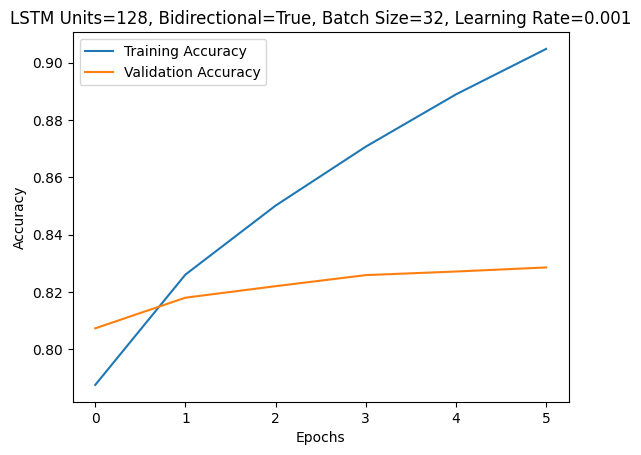

In [11]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128       
bidirectional = True   
batch_size = 32        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dropout(0.5)) # REGULARIZATION: dropout layer
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3) # REGULARIZATION: EARLY_STOPPING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
model.save("lstm_model_1_reg.h5")
plt.savefig("model1reg_plot")

<Figure size 640x480 with 0 Axes>

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


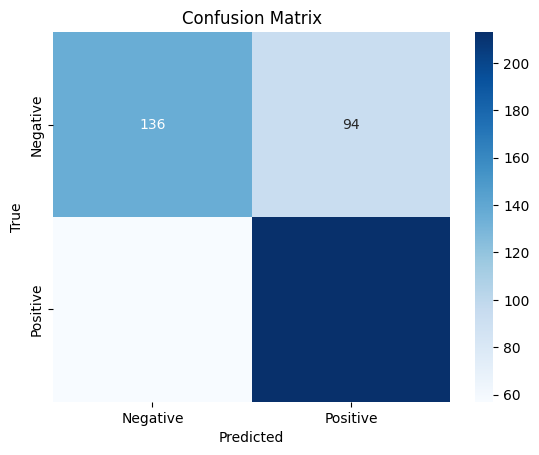

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.59      0.64       230
    Positive       0.69      0.79      0.74       270

    accuracy                           0.70       500
   macro avg       0.70      0.69      0.69       500
weighted avg       0.70      0.70      0.69       500



In [13]:
# Predict and display confusion matrix
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

In [14]:
plt.savefig('model1reg_cr.png')

<Figure size 640x480 with 0 Axes>

In [20]:
accuracy_score(y_pred, y_val)

0.698

## Model 2

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 246s 78ms/step - accuracy: 0.7553 - loss: 0.4947 - val_accuracy: 0.8076 - val_loss: 0.4191
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 242s 77ms/step - accuracy: 0.8279 - loss: 0.3811 - val_accuracy: 0.8166 - val_loss: 0.4072
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 238s 76ms/step - accuracy: 0.8529 - loss: 0.3327 - val_accuracy: 0.8201 - val_loss: 0.4050
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 239s 77ms/step - accuracy: 0.8747 - loss: 0.2902 - val_accuracy: 0.8220 - val_loss: 0.4199
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 240s 77ms/step - accuracy: 0.8940 - loss: 0.2489 - val_accuracy: 0.8268 - val_loss: 0.4539
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 239s 76ms/step - accuracy: 0.9115 - loss: 0.2103 - val_accuracy: 0.8277 - val_loss: 0.4894
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 236s 76ms/step - accuracy: 0.9281 - loss: 0.1742 - val_accuracy: 0.8277 - val_loss: 0.5584
Epoch 8/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 235s 75ms/step - accuracy: 0.9422 - lo

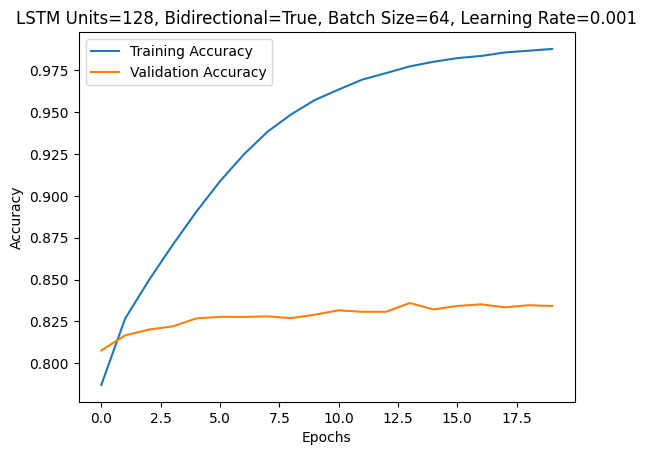

In [21]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128       
bidirectional = True   
batch_size = 64        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [22]:
model.save("lstm_model_2.h5")
plt.savefig("model2_plot")

<Figure size 640x480 with 0 Axes>

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


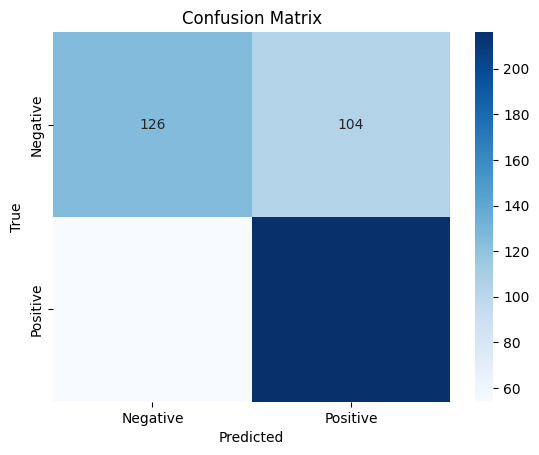

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.55      0.61       230
    Positive       0.68      0.80      0.73       270

    accuracy                           0.68       500
   macro avg       0.69      0.67      0.67       500
weighted avg       0.69      0.68      0.68       500



<Figure size 640x480 with 0 Axes>

In [23]:
# Predict and display confusion matrix
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

plt.savefig('model2_cr.png')

## Model 2 - Regularization

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 251s 80ms/step - accuracy: 0.7540 - loss: 0.4983 - val_accuracy: 0.8048 - val_loss: 0.4220
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 243s 78ms/step - accuracy: 0.8243 - loss: 0.3877 - val_accuracy: 0.8109 - val_loss: 0.4189
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 239s 77ms/step - accuracy: 0.8482 - loss: 0.3433 - val_accuracy: 0.8196 - val_loss: 0.4114
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 238s 76ms/step - accuracy: 0.8670 - loss: 0.3039 - val_accuracy: 0.8200 - val_loss: 0.4217
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 235s 75ms/step - accuracy: 0.8837 - loss: 0.2679 - val_accuracy: 0.8240 - val_loss: 0.4298
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 236s 75ms/step - accuracy: 0.9004 - loss: 0.2329 - val_accuracy: 0.8238 - val_loss: 0.4780
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7285 - loss: 1.2421
Test Loss: 1.2282708883285522
Test Accuracy: 0.7279999852180481


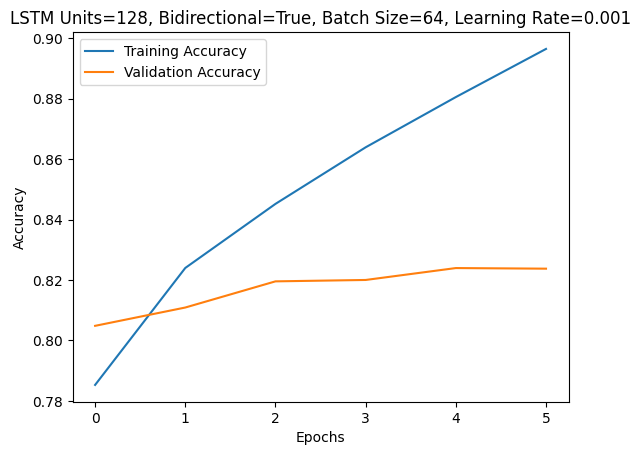

In [24]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128       
bidirectional = True   
batch_size = 64        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dropout(0.5)) # REGULARIZATION: dropout layer
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3) # REGULARIZATION: EARLY_STOPPING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [25]:
model.save("lstm_model_2_reg.h5")
plt.savefig("model2reg_plot")

<Figure size 640x480 with 0 Axes>

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


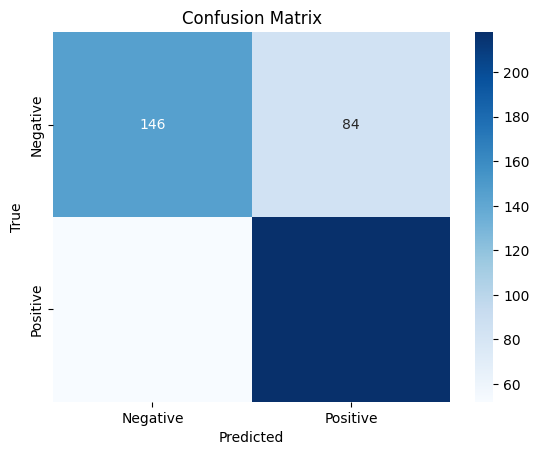

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.63      0.68       230
    Positive       0.72      0.81      0.76       270

    accuracy                           0.73       500
   macro avg       0.73      0.72      0.72       500
weighted avg       0.73      0.73      0.73       500



<Figure size 640x480 with 0 Axes>

In [26]:
# Predict and display confusion matrix
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

plt.savefig('model2reg_cr.png')

## Model 3

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2024-12-08 12:43:01.432865: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 209s 132ms/step - accuracy: 0.7460 - loss: 0.5045 - val_accuracy: 0.8033 - val_loss: 0.4238
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - accuracy: 0.8219 - loss: 0.3910 - val_accuracy: 0.8134 - val_loss: 0.4110
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 127ms/step - accuracy: 0.8423 - loss: 0.3510 - val_accuracy: 0.8169 - val_loss: 0.4101
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 197s 126ms/step - accuracy: 0.8632 - loss: 0.3136 - val_accuracy: 0.8218 - val_loss: 0.4171
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.8844 - loss: 0.2711 - val_accuracy: 0.8235 - val_loss: 0.4350
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.8983 - loss: 0.2412 - val_accuracy: 0.8242 - val_loss: 0.4677
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.9125 - loss: 0.2094 - val_accuracy: 0.8278 - val_loss: 0.5094
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.9

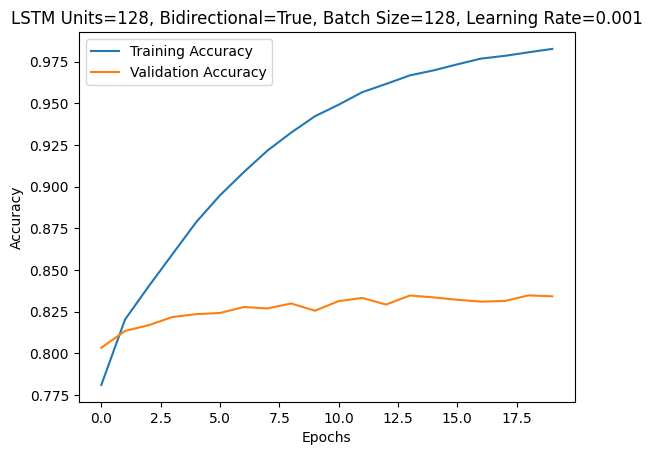

In [6]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128       
bidirectional = True   
batch_size = 128        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [7]:
model.save("lstm_model_3.h5")
plt.savefig("model3_plot")

<Figure size 640x480 with 0 Axes>

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step


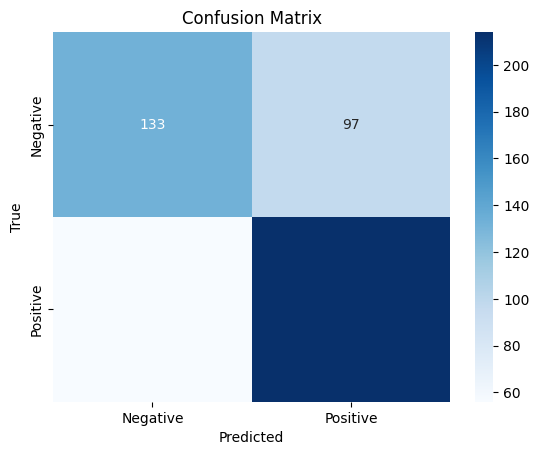

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.58      0.63       230
    Positive       0.69      0.79      0.74       270

    accuracy                           0.69       500
   macro avg       0.70      0.69      0.69       500
weighted avg       0.70      0.69      0.69       500



<Figure size 640x480 with 0 Axes>

In [8]:
# Predict and display confusion matrix
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

plt.savefig('model3_cr.png')

## Model 3 - Regularization

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 211s 133ms/step - accuracy: 0.7389 - loss: 0.5108 - val_accuracy: 0.8060 - val_loss: 0.4246
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 129ms/step - accuracy: 0.8206 - loss: 0.3954 - val_accuracy: 0.8140 - val_loss: 0.4091
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.8416 - loss: 0.3542 - val_accuracy: 0.8177 - val_loss: 0.4098
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 194s 124ms/step - accuracy: 0.8602 - loss: 0.3180 - val_accuracy: 0.8205 - val_loss: 0.4123
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 124ms/step - accuracy: 0.8781 - loss: 0.2828 - val_accuracy: 0.8251 - val_loss: 0.4312
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7205 - loss: 1.1317
Test Loss: 1.0973345041275024
Test Accuracy: 0.7179999947547913


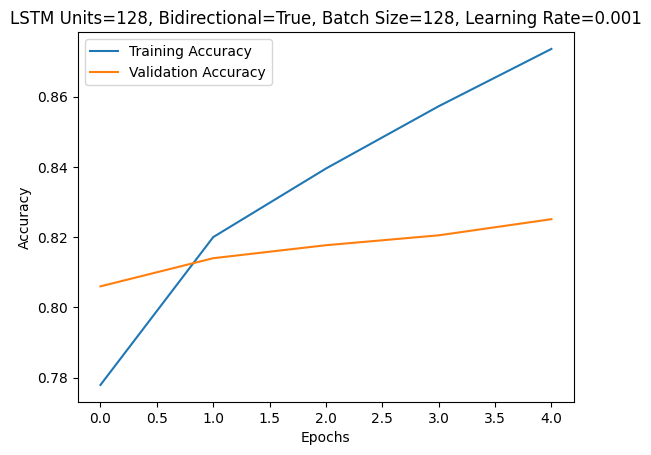

In [9]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128       
bidirectional = True   
batch_size = 128        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dropout(0.5)) # REGULARIZATION: dropout layer
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3) # REGULARIZATION: EARLY_STOPPING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
model.save("lstm_model_3reg.h5")
plt.savefig("model3reg_plot")

<Figure size 640x480 with 0 Axes>

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


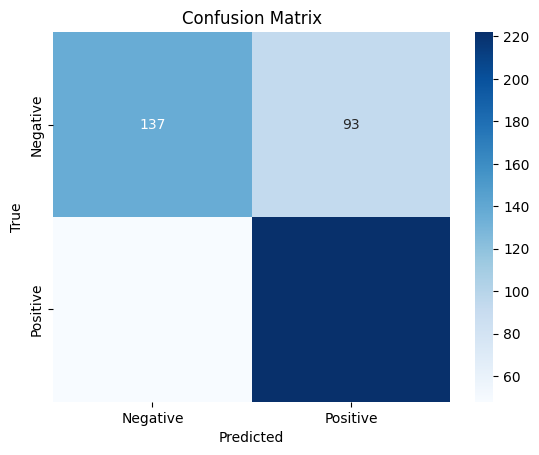

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.60      0.66       230
    Positive       0.70      0.82      0.76       270

    accuracy                           0.72       500
   macro avg       0.72      0.71      0.71       500
weighted avg       0.72      0.72      0.71       500



<Figure size 640x480 with 0 Axes>

In [11]:
# Predict and display confusion matrix
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

plt.savefig('model3reg_cr.png')

## Model 4

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2024-12-08 15:21:21.185170: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 354s 56ms/step - accuracy: 0.7620 - loss: 0.4857 - val_accuracy: 0.8084 - val_loss: 0.4199
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 345s 55ms/step - accuracy: 0.8320 - loss: 0.3763 - val_accuracy: 0.8121 - val_loss: 0.4170
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 340s 54ms/step - accuracy: 0.8498 - loss: 0.3412 - val_accuracy: 0.8093 - val_loss: 0.4222
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 338s 54ms/step - accuracy: 0.8596 - loss: 0.3233 - val_accuracy: 0.8164 - val_loss: 0.4143
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 340s 54ms/step - accuracy: 0.8683 - loss: 0.3061 - val_accuracy: 0.8163 - val_loss: 0.4208
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 343s 55ms/step - accuracy: 0.8719 - loss: 0.2984 - val_accuracy: 0.8159 - val_loss: 0.4265
Epoch 7/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 343s 55ms/step - accuracy: 0.8758 - loss: 0.2910 - val_accuracy: 0.8146 - val_loss: 0.4310
Epoch 8/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 340s 54ms/step - accuracy: 0.8768 - lo

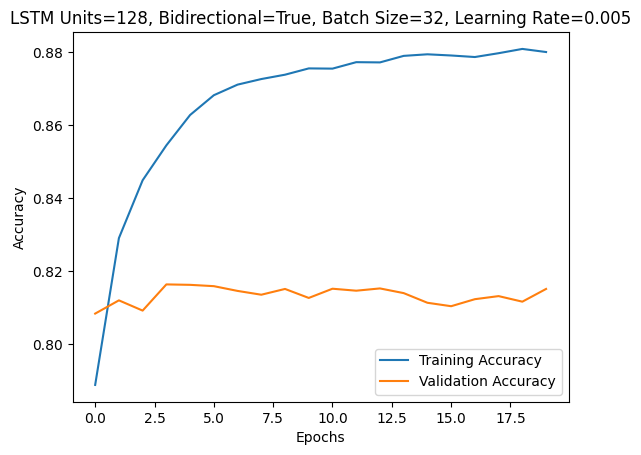

In [6]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128      
bidirectional = True   
batch_size = 32        
learning_rate = 0.005 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [7]:
model.save("lstm_model_4.h5")
plt.savefig("model4_plot")

<Figure size 640x480 with 0 Axes>

In [15]:
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
confusion_matrix(y_val, y_pred)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[132,  98],
       [ 51, 219]])

In [16]:
accuracy_score(y_pred, y_val)

0.702

In [11]:
model.save('saved_model/model_4.h5')


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


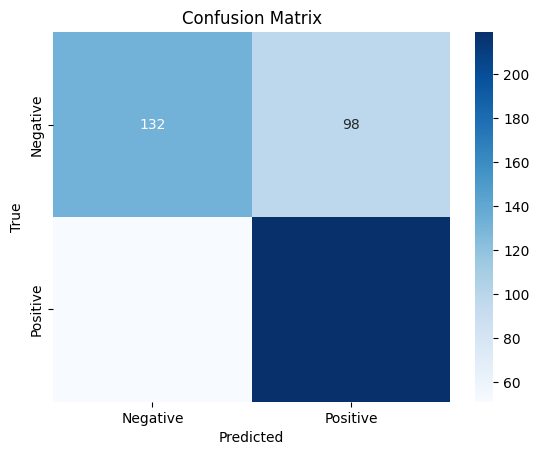

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.57      0.64       230
    Positive       0.69      0.81      0.75       270

    accuracy                           0.70       500
   macro avg       0.71      0.69      0.69       500
weighted avg       0.70      0.70      0.70       500



<Figure size 640x480 with 0 Axes>

In [14]:
# Predict and display confusion matrix
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

plt.savefig('model4_cr.png')

## Model 4 - Regularization

Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 368s 59ms/step - accuracy: 0.7539 - loss: 0.4980 - val_accuracy: 0.8057 - val_loss: 0.4205
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 360s 58ms/step - accuracy: 0.8251 - loss: 0.3870 - val_accuracy: 0.8160 - val_loss: 0.4064
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 351s 56ms/step - accuracy: 0.8525 - loss: 0.3367 - val_accuracy: 0.8193 - val_loss: 0.4088
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 343s 55ms/step - accuracy: 0.8734 - loss: 0.2937 - val_accuracy: 0.8219 - val_loss: 0.4127
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 342s 55ms/step - accuracy: 0.8911 - loss: 0.2548 - val_accuracy: 0.8273 - val_loss: 0.4401
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7187 - loss: 0.8701
Test Loss: 1.0026676654815674
Test Accuracy: 0.699999988079071


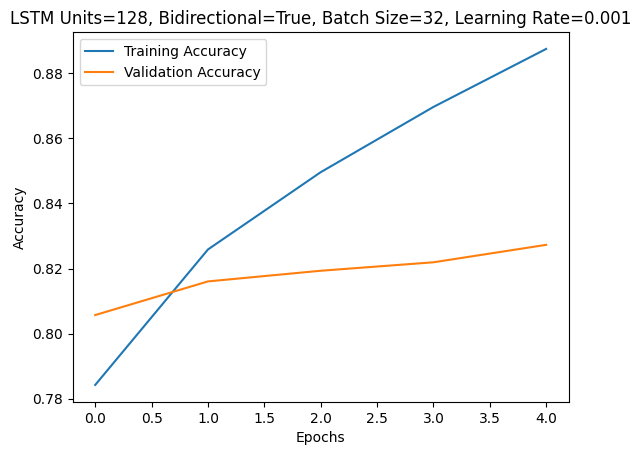

In [17]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128       
bidirectional = True   
batch_size = 32        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dropout(0.5)) # REGULARIZATION: dropout layer
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3) # REGULARIZATION: EARLY_STOPPING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_pred, y_val))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
[[126 104]
 [ 46 224]]
0.7


## Model 4 - Plus

/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2024-12-08 18:00:33.706750: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 380s 60ms/step - accuracy: 0.7556 - loss: 0.5004 - val_accuracy: 0.8076 - val_loss: 0.4169
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 359s 57ms/step - accuracy: 0.8323 - loss: 0.3812 - val_accuracy: 0.8187 - val_loss: 0.4013
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 356s 57ms/step - accuracy: 0.8609 - loss: 0.3238 - val_accuracy: 0.8242 - val_loss: 0.4005
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 360s 58ms/step - accuracy: 0.8843 - loss: 0.2757 - val_accuracy: 0.8270 - val_loss: 0.4206
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 351s 56ms/step - accuracy: 0.9056 - loss: 0.2272 - val_accuracy: 0.8302 - val_loss: 0.4641
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 356s 57ms/step - accuracy: 0.9234 - loss: 0.1858 - val_accuracy: 0.8311 - val_loss: 0.5077
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7378 - loss: 1.2697
Test Loss: 1.3154606819152832
Test Accuracy: 0.722000002861023


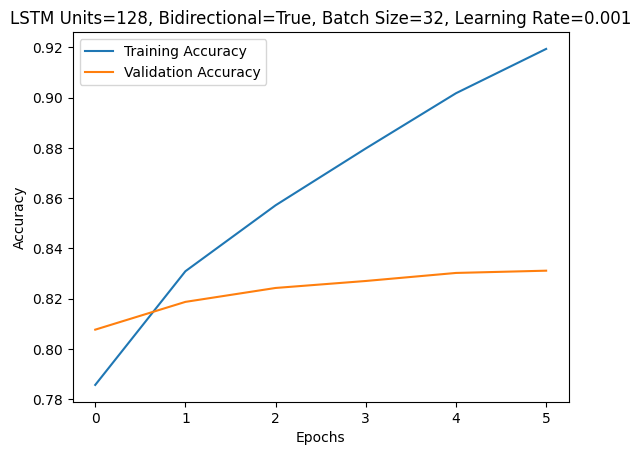

In [8]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128      
bidirectional = True   
batch_size = 32        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dense(64, activation="relu")) # added Dense layer for higher capacity 
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3) # REGULARIZATION: EARLY_STOPPING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    callbacks = [early_stopping],
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [9]:
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_pred, y_val))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
[[145  85]
 [ 54 216]]
0.722


Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 394s 63ms/step - accuracy: 0.7573 - loss: 0.4944 - val_accuracy: 0.8087 - val_loss: 0.4191
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 374s 60ms/step - accuracy: 0.8323 - loss: 0.3752 - val_accuracy: 0.8199 - val_loss: 0.4023
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 363s 58ms/step - accuracy: 0.8621 - loss: 0.3209 - val_accuracy: 0.8247 - val_loss: 0.4089
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 355s 57ms/step - accuracy: 0.8869 - loss: 0.2703 - val_accuracy: 0.8283 - val_loss: 0.4332
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 351s 56ms/step - accuracy: 0.9098 - loss: 0.2216 - val_accuracy: 0.8299 - val_loss: 0.4540
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7089 - loss: 1.1344
Test Loss: 1.1249852180480957
Test Accuracy: 0.7160000205039978


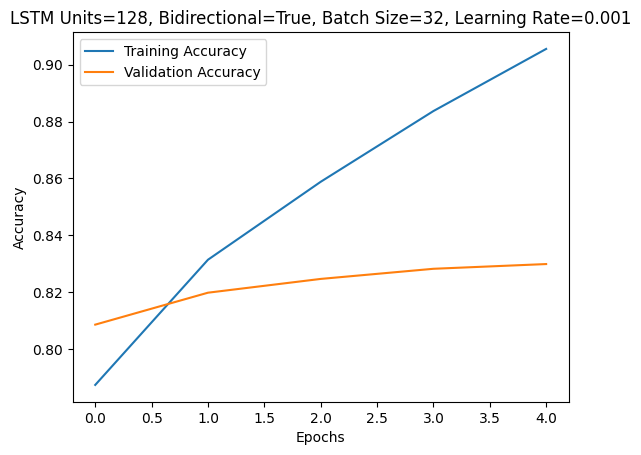

In [10]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 128      
bidirectional = True   
batch_size = 32        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dense(128, activation="relu")) # added Dense layer for higher capacity
    model.add(Dense(128, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3) # REGULARIZATION: EARLY_STOPPING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    callbacks = [early_stopping],
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [11]:
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_pred, y_val))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
[[134  96]
 [ 46 224]]
0.716


Epoch 1/20


/usr4/ds340/crwhitt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 506s 81ms/step - accuracy: 0.7542 - loss: 0.4968 - val_accuracy: 0.8075 - val_loss: 0.4184
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 491s 79ms/step - accuracy: 0.8287 - loss: 0.3829 - val_accuracy: 0.8175 - val_loss: 0.4090
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 520s 83ms/step - accuracy: 0.8541 - loss: 0.3339 - val_accuracy: 0.8211 - val_loss: 0.4066
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 494s 79ms/step - accuracy: 0.8766 - loss: 0.2884 - val_accuracy: 0.8251 - val_loss: 0.4179
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 491s 79ms/step - accuracy: 0.8948 - loss: 0.2470 - val_accuracy: 0.8271 - val_loss: 0.4385
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 500s 80ms/step - accuracy: 0.9125 - loss: 0.2081 - val_accuracy: 0.8306 - val_loss: 0.4831
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6802 - loss: 1.4069
Test Loss: 1.3793954849243164
Test Accuracy: 0.6700000166893005


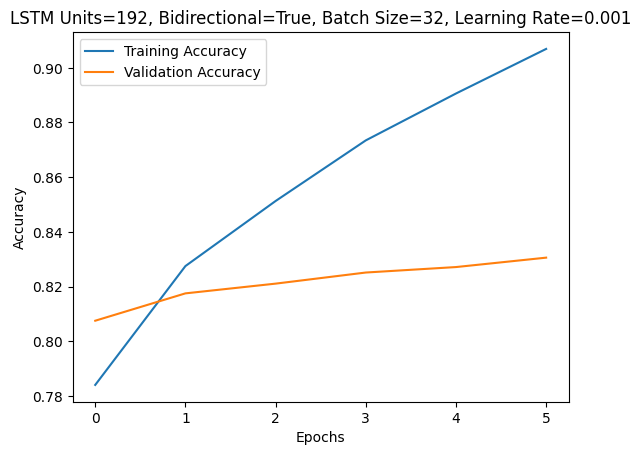

In [20]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. Label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

# 4. Parameters
lstm_units = 192      
bidirectional = True   
batch_size = 32        
learning_rate = 0.001 

# 5. Function to build a single LSTM model
def build_model(vocab_size, embedding_dim, max_sequence_length, lstm_units, bidirectional, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units)))
    else:
        model.add(LSTM(lstm_units))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation="relu")) # added Dense layer for higher capacity
    model.add(Dropout(0.25))
    model.add(Dense(1, activation='sigmoid')) 
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(len(word_index) + 1, 100, 100, lstm_units, bidirectional, learning_rate)

# 6. Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3) # REGULARIZATION: EARLY_STOPPING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=batch_size,
    callbacks = [early_stopping],
    verbose=1
)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_val, y_val, batch_size=batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 8. Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"LSTM Units={lstm_units}, Bidirectional={bidirectional}, Batch Size={batch_size}, Learning Rate={learning_rate}")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [21]:
y_pred = (model.predict(X_val, batch_size=batch_size) > 0.5).astype("int32")
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_pred, y_val))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
[[120 110]
 [ 55 215]]
0.67


## Random Search

In [6]:
X = data['Tweet'].astype(str)
y = data['sentiment']

X_val = test_set['text'].astype(str)
y_val = test_set['sentiment']

# 1. label mapping
label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[label] for label in y])
y_val = np.array([label_map[label] for label in y_val])

# 2. Tokenizing
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=100)
val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=100)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=340)

In [ ]:
def build_tunable_model(hp):
    model = Sequential()
    model.add(Embedding(input_dim=10000, output_dim=hp.Choice('embedding_dim', [50, 100, 200]), input_length=100))
    model.add(Bidirectional(LSTM(units=hp.Int('lstm_units', min_value=64, max_value=256, step=64))))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(hp.Choice('dropout', [0.3, 0.5])))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])), 
                  loss="binary_crossentropy", 
                  metrics=["accuracy"])
    return model

tuner = RandomSearch(
    build_tunable_model, 
    objective='val_accuracy', 
    max_trials=10, 
    executions_per_trial=1
)
tuner.search(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=32)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]


Trial 2 Complete [00h 57m 02s]
val_accuracy: 0.8217999935150146

Best val_accuracy So Far: 0.8289600014686584
Total elapsed time: 01h 38m 38s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
100               |100               |embedding_dim
192               |192               |lstm_units
0.5               |0.3               |dropout
0.0001            |0.001             |learning_rate

Epoch 1/5
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 499s 79ms/step - accuracy: 0.7103 - loss: 0.5463 - val_accuracy: 0.7950 - val_loss: 0.4405
Epoch 2/5
 972/6250 ━━━━━━━━━━━━━━━━━━━━ 6:10 70ms/step - accuracy: 0.8083 - loss: 0.4288